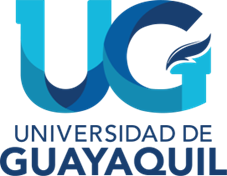


  # **PROCESAMIENTO DE LENGUAJE NATURAL**
  
Docente: Angel Eduardo Cuenca Ortega

    

  # PROYECTO PARCIAL II
    Paralelo: CDDEIA-ELNO-4-2   |   4to Semestre

  GRUPO PI-G2 conformado por:

*     Sergio Bernard Luna Vasquez
*     Alejandra Janelly Salavarria Estrada
*     Johnny Aarón Ortíz López



# Fase 1: Configuración del Entorno y librerías


## Importación de Librerías y Carga del Pipeline Lingüístico

In [21]:
import os                       # Gestión de rutas de archivos y carpetas locales
import re                       # Expresiones regulares para la extracción de entidades
import json                     # Lectura/escritura de los archivos de datos
import random                   # Selección aleatoria
import numpy as np              # Operaciones para TF-IDF y similitud coseno
import pandas as pd             # Estructuración de datos para inspección y reportes
import seaborn as sns           # Visualización estadística de la matriz de confusión
import matplotlib.pyplot as plt # Renderizado de gráficos y figuras para los reportes métricos
import gradio as gr             # Creación de la interfaz gráfica interactiva para el usuario final
import sys                      # Localiza el ejecutable de Python para instalar librerías
import unicodedata              # Permite normalizar texto y eliminar tildes de forma universal

import shutil                   # Permitir operaciones como borrar, mover o copiar carpetas con archivos
import subprocess               # Ejecutar comandos del sistema (como pip install o git clone)

# Importaciones de módulos para evaluación del modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Instalación de **spaCy** y descarga del modelo lingüístico para español (`es_core_news_sm`).

In [22]:
try:
    import spacy
except ImportError:
    print("Instalando spaCy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "spacy"])
    import spacy

try:
    # Desactivar ner' y 'parser' para uso de lemas, no sintaxis ni entidades.
    modelo_linguistico_es = spacy.load("es_core_news_sm", disable=["ner", "parser"])
    print("Modelo 'es_core_news_sm' listo.")
except OSError:
    print("Descargando el modelo 'es_core_news_sm'...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "es_core_news_sm"])
    modelo_linguistico_es = spacy.load("es_core_news_sm", disable=["ner", "parser"])


Modelo 'es_core_news_sm' listo.


# Fase 2: Carga del Corpus y las Entidades desde el Repositorio de Datos (`data/`)

Aquí se leerá los archivos `data/corpus.json`, `data/entidades.json` y `data/base_conocimiento.json`

In [23]:
# Rutas de los archivos fuente (carpeta data/)
CARPETA_DATA = "data"

# Seleccionar los Documentos objetivos
RUTA_CORPUS_JSON = os.path.join(CARPETA_DATA, "corpus.json")
RUTA_ENTIDADES_JSON = os.path.join(CARPETA_DATA, "entidades.json")
RUTA_CONOCIMIENTO_JSON = os.path.join(CARPETA_DATA, "base_conocimiento.json")

# URL del Repositorio del proyecto alojado en GitHub
URL_REPOSITORIO_GITHUB = "https://github.com/JohnnyMeta/PLN-Proyecto-parcial-2-GRUPO-PI-G2.git"



def sincronizar_carpeta_data(url_repositorio=URL_REPOSITORIO_GITHUB):
    """Garantiza la existencia de data/ local y descarga todos los archivos
    JSON de GitHub (corpus, entidades, conocimiento).
    """
    # Se crea la carpeta en el entorno para permitir la subida manual
    if not os.path.exists(CARPETA_DATA):
        os.makedirs(CARPETA_DATA)
        print(f"Creada la carpeta local '{CARPETA_DATA}/' en el entorno.")

    nombre_repo = url_repositorio.rstrip("/").split("/")[-1].replace(".git", "")

    try:
        if not os.path.exists(nombre_repo):
            print(f"Clonando repositorio: {url_repositorio}")
            resultado = subprocess.run(
                ["git", "clone", url_repositorio],
                capture_output=True,
                text=True,
                timeout=30,
            )
        else:
            print(
                "Repositorio ya clonado localmente, actualizando con 'git pull'"
            )
            resultado = subprocess.run(
                ["git", "-C", nombre_repo, "pull"],
                capture_output=True,
                text=True,
                timeout=30,
            )

        if resultado.returncode != 0:
            raise RuntimeError(resultado.stderr.strip())

        ruta_data_repo = os.path.join(nombre_repo, "data")
        if not os.path.isdir(ruta_data_repo):
            raise FileNotFoundError(
                f"No se encontró la carpeta 'data/' dentro de '{nombre_repo}'."
            )

        # Copia todos los JSON que existan en el repositorio remoto hacia 'data/' local
        for elemento in os.listdir(ruta_data_repo):
            ruta_origen = os.path.join(ruta_data_repo, elemento)
            ruta_destino = os.path.join(CARPETA_DATA, elemento)

            if os.path.isdir(ruta_origen):
                if os.path.exists(ruta_destino):
                    shutil.rmtree(ruta_destino)
                shutil.copytree(ruta_origen, ruta_destino)
            else:
                shutil.copy2(ruta_origen, ruta_destino)

        print("Sincronización masiva desde GitHub completada.")

    except Exception as error:
        print(
            f"Aviso: No se pudo sincronizar con GitHub ({error}). Se utilizará el almacenamiento local."
        )

    # Validación del contenido de la carpeta
    archivos_locales = os.listdir(CARPETA_DATA)
    if archivos_locales:
        print(
            f"Archivos listos en '{CARPETA_DATA}/' para trabajar: {archivos_locales}"
        )
    else:
        print(f"\n     La carpeta '{CARPETA_DATA}/' está vacía.")
        print(
            "Es necesario colocar los archivos j.son de 'corpus.json' y 'entidades.json', de forma manual en la carpeta data."
        )


def cargar_corpus_desde_json():
    """Lee corpus.json y distribuye los datos en estructuras paralelas."""
    if not os.path.exists(RUTA_CORPUS_JSON):
        raise FileNotFoundError(
            f"Falta el archivo esencial '{RUTA_CORPUS_JSON}'."
        )

    with open(RUTA_CORPUS_JSON, mode="r", encoding="utf-8") as archivo:
        corpus_json = json.load(archivo)

    etiquetas_intencion = []
    frases_usuario = []
    respuestas_por_intencion = {}

    for nombre_intencion, datos_intencion in corpus_json.items():
        respuestas_por_intencion[nombre_intencion] = datos_intencion[
            "responses"
        ]
        for utterance in datos_intencion["utterances"]:
            etiquetas_intencion.append(nombre_intencion)
            frases_usuario.append(utterance)

    return etiquetas_intencion, frases_usuario, respuestas_por_intencion


def cargar_entidades_desde_json():
    """Lee entidades.json para el procesamiento de expresiones regulares."""
    if not os.path.exists(RUTA_ENTIDADES_JSON):
        raise FileNotFoundError(
            f"Falta el archivo esencial '{RUTA_ENTIDADES_JSON}'."
        )

    with open(RUTA_ENTIDADES_JSON, mode="r", encoding="utf-8") as archivo:
        return json.load(archivo)


def cargar_base_conocimiento_desde_json():
    """Lee base_conocimiento.json (generado por 03_generar_base_conocimiento.ipynb)."""
    if not os.path.exists(RUTA_CONOCIMIENTO_JSON):
        raise FileNotFoundError(
            f"Falta el archivo esencial '{RUTA_CONOCIMIENTO_JSON}'."
        )

    with open(RUTA_CONOCIMIENTO_JSON, mode="r", encoding="utf-8") as archivo:
        return json.load(archivo)


"""
    Intenta descargar o actualizar el corpus desde el repositorio.
    Si falla, se gestiona de manera interna y manual.
"""
sincronizar_carpeta_data()


"""
    Garantiza que, si no existen los archivos necesarios (ni de forma remota
    ni local), la ejecución se detenga y se envie un mensaje.
"""
try:
    ENTIDADES_JSON = cargar_entidades_desde_json()
    BASE_CONOCIMIENTO_JSON = cargar_base_conocimiento_desde_json()
    ETIQUETAS, FRASES, RESPUESTAS = cargar_corpus_desde_json()
    print("\nLos archivos JSON fueron cargados con éxito.")

except FileNotFoundError as error:
    print(f"\n[ERROR DE CARGA] {error}")
    print(
        "Fallo con la URL, se requiere verificar el enlace al repositorio GitHub o subir los archivos necesarios de forma manual a la carpeta 'data/' del presente entorno"
    )

Repositorio ya clonado localmente, actualizando con 'git pull'
Sincronización masiva desde GitHub completada.
Archivos listos en 'data/' para trabajar: ['entidades.json', 'banner_ug.jpg', 'base_conocimiento.json', 'corpus.json']

Los archivos JSON fueron cargados con éxito.


# Fase 3: Preprocesamiento Lingüístico



## Normalización, Tokenización y Lematización

Toda oración sea del corpus o la consulta en vivo de un estudiante,  pasa por el mismo proceso de limpieza: de minúsculas, eliminación de tildes, tokenización, remoción de stopwords y signos de puntuación, y lematización.

El objetivo es alcanzar la raíz lingüística de las palabras.

Finalmente se compartirán diferencias de antes y después de la lematización.

In [24]:
def eliminar_tildes(texto):
    return "".join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')


def preprocesar_texto(texto_entrada):
    """
    Pipeline de preprocesamiento lingüístico:
      1) minúsculas,
      2) eliminación de tildes,
      3) tokenización,
      4) lematización vía spaCy,
      5) filtrado de:
            puntuación,
            espacios,
            stopwords y
            números

    Devuelve las raíces lematizadas unidas por espacios para luego vectorizar.
    """
    texto_normalizado = eliminar_tildes(texto_entrada.lower().strip())
    documento_spacy = modelo_linguistico_es(texto_normalizado)

    lemas_relevantes = [
        token.lemma_
        for token in documento_spacy
        if not token.is_punct
        and not token.is_space
        and not token.is_stop
        and not token.like_num
    ]
    return " ".join(lemas_relevantes)



# Demostración del preprocesamiento aplicado a una frase
etiquetas_intencion, frases_usuario, respuestas_por_intencion = cargar_corpus_desde_json()

oracion_ejemplo = "¿Cuándo empezarán las inscripciones para la nivelación?"
print("Demostración de lematización:\n")
print(f"  Original : '{oracion_ejemplo}'")
print(f"  Procesada: '{preprocesar_texto(oracion_ejemplo)}'\n")


# Demostración del preprocesamiento aplicado a 10 utterances al azar del corpus
MUESTRA_DEMOSTRACION = random.sample(list(zip(etiquetas_intencion, frases_usuario)), k=10)
frases_lematizadas_demostracion = [preprocesar_texto(frase) for _, frase in MUESTRA_DEMOSTRACION]

for (intencion, frase_original), frase_limpia in zip(MUESTRA_DEMOSTRACION, frases_lematizadas_demostracion):
    print(f"\nIntención [{intencion}]")
    print(f"    Original:   '{frase_original}'")
    print(f"    Procesada:  '{frase_limpia}'")

Demostración de lematización:

  Original : '¿Cuándo empezarán las inscripciones para la nivelación?'
  Procesada: 'empezar inscripción nivelacion'


Intención [consultar_carrera_especifica]
    Original:   'como es diseño gráfico'
    Procesada:  'diseno grafico'

Intención [consultar_asignacion_cupos]
    Original:   'como eligen quien entra'
    Procesada:  'elegir entrar'

Intención [consultar_requisitos_matricula_nivelacion]
    Original:   'requisitos de matricula'
    Procesada:  'requisito matricula'

Intención [consultar_por_que_estudiar_ug]
    Original:   'por que me conviene estudiar aqui'
    Procesada:  'convenir estudiar'

Intención [consultar_carrera_especifica]
    Original:   'informacion sobre medicina veterinaria'
    Procesada:  'informacion medicina veterinario'

Intención [consultar_carrera_especifica]
    Original:   'como es obstetricia'
    Procesada:  'obstetricia'

Intención [explicar_creacion_cuenta]
    Original:   'como hago mi cuenta'
    Procesada:  ''


# Fase 4: Representación Vectorial TF-IDF

Implementación de TF-IDF

- $\text{TF}(t, d)$ = frecuencia cruda del término *t* en el documento *d* (conteo simple).
- $\text{IDF}(t) = \log(N / \text{df}(t))$, donde $N$ es el número total de documentos (*utterances*) y $\text{df}(t)$ el número de documentos donde aparece $t$.

Un IDF alto significa que el término es raro y por tanto más informativo.
- $\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$

In [25]:
def construir_vocabulario(textos_lematizados):
    """Lista ordenada y sin duplicados de todas las palabras únicas del corpus."""
    todas_las_palabras = []
    for texto in textos_lematizados:
        todas_las_palabras.extend(texto.split())
    return list(dict.fromkeys(todas_las_palabras))  # conserva el orden de aparición


def calcular_matriz_tf(textos_lematizados, vocabulario):
    """
    TF(t,d) = frecuencia de t en d
    Ejemplo:
    Documento 'caballero andante aventura caballero' -> TF(caballero) = 2).
    """
    matriz_tf = []
    for texto in textos_lematizados:
        palabras_documento = texto.split()
        fila_tf = [palabras_documento.count(palabra) for palabra in vocabulario]
        matriz_tf.append(fila_tf)
    return np.array(matriz_tf)


def calcular_vector_idf(textos_lematizados, vocabulario):
    """
    IDF(t) = log(N / df(t))
    N = número total de documentos (utterances del corpus).
    df(t) = número de documentos en los que aparece el término t.
    """
    N = len(textos_lematizados)
    vector_idf = []
    for palabra in vocabulario:
        df = sum(1 for texto in textos_lematizados if palabra in texto.split())
        vector_idf.append(np.log(N / df))  # df nunca es 0: la palabra viene del vocabulario del corpus
    return np.array(vector_idf)


def entrenar_modelo_tfidf():
    """
    Función que:
        1) carga el corpus,
        2) lo preprocesa y
        3) calcula la matriz TF-IDF
    """

    # Usar global, para crear variables globales
    global VOCABULARIO, VECTOR_IDF, MATRIZ_TFIDF, ETIQUETAS_INTENCION, RESPUESTAS_POR_INTENCION

    ETIQUETAS_INTENCION, frases_originales, RESPUESTAS_POR_INTENCION = cargar_corpus_desde_json()
    frases_lematizadas = [preprocesar_texto(frase) for frase in frases_originales]

    VOCABULARIO = construir_vocabulario(frases_lematizadas)
    matriz_tf = calcular_matriz_tf(frases_lematizadas, VOCABULARIO)
    VECTOR_IDF = calcular_vector_idf(frases_lematizadas, VOCABULARIO)
    MATRIZ_TFIDF = matriz_tf * VECTOR_IDF  # TF-IDF(t,d) = TF(t,d) x IDF(t), por np - NumPy

    print("Modelo TF-IDF entrenado.")
    print(f"   - Tamaño del vocabulario: {len(VOCABULARIO)} términos únicos.")
    print(f"   - Dimensiones de la matriz TF-IDF: {MATRIZ_TFIDF.shape} (frases x términos).")


entrenar_modelo_tfidf()

Modelo TF-IDF entrenado.
   - Tamaño del vocabulario: 329 términos únicos.
   - Dimensiones de la matriz TF-IDF: (749, 329) (frases x términos).


# Fase 5: Detección de Intención por Similitud Coseno

Toda consulta nueva se vectoriza con el mismo vocabulario e IDF del corpus entrenado, y se compara contra cada fila de la matriz TF-IDF mediante **similitud coseno**: el coseno del ángulo entre el vector de la consulta y el vector de cada *utterance* del corpus. La intención asociada a la fila con mayor similitud es la intención detectada.

$$\text{sim}(d, q) = \cos(\theta) = \frac{\vec{d} \cdot \vec{q}}{\|\vec{d}\| \|\vec{q}\|}$$

*(En código: `coseno(A, B) = (A . B) / (||A|| * ||B||)`)*

In [26]:
def vectorizar_consulta(consulta_lematizada, vocabulario, vector_idf):
    """Convierte la consulta del usuario en un vector TF-IDF, usando el mismo
    vocabulario e IDF aprendidos del corpus (criterio TF: conteo crudo)."""
    palabras_consulta = consulta_lematizada.split()
    fila_tf = [palabras_consulta.count(palabra) for palabra in vocabulario]
    return np.array(fila_tf) * vector_idf


def similitud_coseno(vector_a, vector_b):
    """coseno(A,B) = (A . B) / (||A|| * ||B||)"""
    producto_punto = np.dot(vector_a, vector_b)
    norma_a = np.linalg.norm(vector_a)
    norma_b = np.linalg.norm(vector_b)

    if norma_a == 0.0 or norma_b == 0.0:
        return 0.0  # sin palabras en común con el vocabulario del corpus

    return producto_punto / (norma_a * norma_b)


def predecir_intencion(consulta_usuario):
    """Determina la intención más probable de una consulta, usando TF-IDF + coseno."""
    consulta_lematizada = preprocesar_texto(consulta_usuario)
    vector_consulta = vectorizar_consulta(consulta_lematizada, VOCABULARIO, VECTOR_IDF)

    similitudes = [similitud_coseno(vector_consulta, fila) for fila in MATRIZ_TFIDF]

    indice_max = int(np.argmax(similitudes))
    similitud_max = similitudes[indice_max]
    intencion_detectada = ETIQUETAS_INTENCION[indice_max]

    return intencion_detectada, similitud_max




# Pruebas
consultas_pruebas = {
    "Prueba 1" : "hola, ocupo ayuda para inscribirme a las nivelaciones",
    "Prueba 2" : "Buenas tardes, ¿cómo estás?",
    "Prueba 3" : "quiero matricularme pero no sé los requisitos",
    "Prueba 4" : "INFORMACION MATRICULA",
    "Prueba 5" : "INFORMACION examen",
    "Prueba 6" : "INFORMACION nivelacion",
    "Prueba 7" : "INFORMACION facultad",
    "Prueba 8" : "INFORMACION carreras",
}
for nombre_prueba, frase_usuario in consultas_pruebas.items():
    intencion_resultado, similitud_resultado = predecir_intencion(frase_usuario)

    print(f"{nombre_prueba}")
    print(f"   Consulta: '{frase_usuario}'")
    print(f"   Intención detectada: '{intencion_resultado}'")
    print(f"   Similitud coseno:    {similitud_resultado:.4f}")

Prueba 1
   Consulta: 'hola, ocupo ayuda para inscribirme a las nivelaciones'
   Intención detectada: 'consultar_fechas_inscripcion'
   Similitud coseno:    0.6446
Prueba 2
   Consulta: 'Buenas tardes, ¿cómo estás?'
   Intención detectada: 'saludo'
   Similitud coseno:    1.0000
Prueba 3
   Consulta: 'quiero matricularme pero no sé los requisitos'
   Intención detectada: 'consultar_requisitos_matricula_nivelacion'
   Similitud coseno:    0.7231
Prueba 4
   Consulta: 'INFORMACION MATRICULA'
   Intención detectada: 'consultar_requisitos_matricula_nivelacion'
   Similitud coseno:    0.9689
Prueba 5
   Consulta: 'INFORMACION examen'
   Intención detectada: 'consultar_cronograma_evaluacion'
   Similitud coseno:    0.9178
Prueba 6
   Consulta: 'INFORMACION nivelacion'
   Intención detectada: 'explicar_curso_nivelacion'
   Similitud coseno:    0.9107
Prueba 7
   Consulta: 'INFORMACION facultad'
   Intención detectada: 'consultar_total_facultades'
   Similitud coseno:    0.9178
Prueba 8
   Con

# Fase 6: Extracción de Entidades por Expresiones Regulares

Los patrones de RegEx se construyen **dinámicamente a partir de `entidades.json`** (facultades, carreras, procesos, documentos y patrones de cédula/fecha).



In [27]:
def construir_patrones_entidades(entidades_json):
    """Construye los patrones RegEx a partir de entidades.json.
    Carreras es un diccionario, se debe usar .values
    Se normaliza los facultades, procesos, documentos que conservabaran tildes

    """

    def normalizar_alias(texto):
        return eliminar_tildes(texto.lower().strip())

    alias_facultades = []
    for facultad in entidades_json["facultades"]:
        alias_facultades.extend(facultad.get("alias", [facultad["nombre"]]))

    alias_carreras = []
    for carrera in entidades_json["carreras"].values():
        alias_carreras.extend(carrera.get("alias", [carrera["nombre"]]))

    alias_procesos = []
    for proceso in entidades_json["procesos"]:
        alias_procesos.extend(proceso.get("alias", [proceso["nombre"]]))

    alias_documentos = []
    for documento in entidades_json["documentos"]:
        alias_documentos.extend(documento.get("alias", [documento["nombre"]]))

    def construir_regex(lista_alias):
        alternativas = "|".join(
            sorted({re.escape(normalizar_alias(alias)) for alias in lista_alias}, key=len, reverse=True)
        )
        return re.compile(rf"\b({alternativas})\b", re.IGNORECASE)

    return {
        "carrera": construir_regex(alias_carreras),
        "facultad": construir_regex(alias_facultades),
        "proceso": construir_regex(alias_procesos),
        "documento": construir_regex(alias_documentos),
        "cedula": re.compile(entidades_json["patrones"]["patrones"]["cedula"]),
        "fecha": re.compile(entidades_json["patrones"]["patrones"]["fecha"], re.IGNORECASE),
        "bloque": re.compile(entidades_json["patrones"]["patrones"]["bloque"], re.IGNORECASE),
    }


PATRONES_ENTIDADES = construir_patrones_entidades(ENTIDADES_JSON)


def _construir_mapa_alias_a_id(coleccion_items):
    mapa = {}
    for item in coleccion_items:
        alias_norm = [eliminar_tildes(a.lower().strip()) for a in item.get("alias", [item["nombre"]])]
        alias_norm.append(eliminar_tildes(item["nombre"].lower().strip()))
        for alias in alias_norm:
            mapa[alias] = item["id"]
    return mapa

MAPA_ALIAS_A_ID_CARRERA = _construir_mapa_alias_a_id(ENTIDADES_JSON["carreras"].values())
MAPA_ALIAS_A_ID_FACULTAD = _construir_mapa_alias_a_id(ENTIDADES_JSON["facultades"])

# Palabras y dígito, para normalizar el patrón 'bloque' (admite "bloque tres" o "bloque 3")
_PALABRA_A_DIGITO_BLOQUE = {
    "uno": "1", "dos": "2", "tres": "3", "cuatro": "4", "cinco": "5", "seis": "6",
}


def _normalizar_bloque_id(valor_capturado):
    """'3' o 'tres' -> 'B3' (formato de id usado en entidades/base_conocimiento)."""
    digito = _PALABRA_A_DIGITO_BLOQUE.get(valor_capturado, valor_capturado)
    return f"B{digito}"



def _construir_mapa_materia_a_bloques(base_conocimiento_json):

    mapa = {}
    for bloque in base_conocimiento_json["bloques_conocimiento"]:
        for materia in bloque["materias"]:
            nombre_norm = eliminar_tildes(materia["materia"].lower()).strip()
            mapa.setdefault(nombre_norm, []).append(bloque["id"])
    return mapa

MAPA_MATERIA_A_BLOQUES = _construir_mapa_materia_a_bloques(BASE_CONOCIMIENTO_JSON)
NOMBRES_MATERIAS_NORMALIZADOS = set(MAPA_MATERIA_A_BLOQUES.keys())

# Palabras que indican que la persona pregunta por el EXAMEN/la MATERIA y no
# por la carrera homónima (cuanto vale biologia, porcentaje de biologia)
_PALABRAS_CONTEXTO_MATERIA = {
    "materia", "materias", "porcentaje", "preguntas", "pregunta",
    "evalua", "evaluan", "vale", "puntaje", "peso", "examen",
}


def _es_alias_ambiguo_con_materia(alias_normalizado):
    """True si el alias de carrera coincide (como palabra completa) con
    el nombre de alguna materia evaluada en el examen."""
    return any(
        re.search(rf"\b{re.escape(alias_normalizado)}\b", materia_norm)
        for materia_norm in NOMBRES_MATERIAS_NORMALIZADOS
    )


def extraer_entidades(texto_usuario):
    """Escanea el texto y extrae entidades del dominio:
        carreras,
        facultades,
        procesos académicos,
        documentos,
        números de cédula y
        fechas.
    """
    entidades_detectadas = {}

    texto_normalizado = eliminar_tildes(texto_usuario.lower())

    for nombre_entidad, patron_regex in PATRONES_ENTIDADES.items():
        texto_a_buscar = texto_usuario if nombre_entidad in ("cedula", "fecha") else texto_normalizado
        coincidencias = patron_regex.findall(texto_a_buscar)
        if not coincidencias:
            continue

        # Procesamiento de coincidencias:
            # re.findall() devuelve una lista de textos planos si el regex no tiene grupos,
            # o una lista de TUPLAS 'c' si el regex usa grupos de captura (parentesis).
        valores_encontrados = [

            # Caso 1: 'c' es una tupla y el primer grupo c[0] tiene el texto extraído
            (c[0] if isinstance(c, tuple) and c[0] else c).lower()
            if not isinstance(c, tuple)
            else
            # Caso 2: 'c' es una tupla pero c[0] está vacío (el texto cayó en otro grupo de captura).
            # 'next(...)' busca y extrae el primer elemento de la tupla que SI contenga el texto.
            (c[0] if c[0] else next(item for item in c if item)).lower()
            for c in coincidencias # 'c' es cada coincidencia (texto o tupla) devuelta por el regex
        ]
        # Guarda las palabras clave limpias y en minúsculas en el diccionario
        entidades_detectadas[nombre_entidad] = valores_encontrados



    # Detectar menciones de materias del examen
    tokens_consulta = set(texto_normalizado.split())
    hay_contexto_materia = bool(tokens_consulta & _PALABRAS_CONTEXTO_MATERIA)

    materias_detectadas = [
        m for m in NOMBRES_MATERIAS_NORMALIZADOS
        if re.search(rf"\b{re.escape(m)}\b", texto_normalizado)
    ]
    if materias_detectadas:
        entidades_detectadas["materia"] = materias_detectadas


    # Manejo de ID's
    if "carrera" in entidades_detectadas:
        # Si el alias de carrera es a la vez el
        # nombre de una materia y hay contexto de examen/materia en el
        # mensaje, se descarta como carrera (se interpreta como la materia)
        alias_validos = []
        for alias in entidades_detectadas["carrera"]:
            ambiguo = _es_alias_ambiguo_con_materia(alias)
            if ambiguo and (hay_contexto_materia or materias_detectadas):
                continue
            alias_validos.append(alias)

        if alias_validos:
            entidades_detectadas["carrera"] = alias_validos
            ids = [MAPA_ALIAS_A_ID_CARRERA[a] for a in alias_validos if a in MAPA_ALIAS_A_ID_CARRERA]
            if ids:
                entidades_detectadas["carrera_ids"] = list(dict.fromkeys(ids))
        else:
            entidades_detectadas.pop("carrera", None)

    if "facultad" in entidades_detectadas:
        ids = [MAPA_ALIAS_A_ID_FACULTAD[a] for a in entidades_detectadas["facultad"] if a in MAPA_ALIAS_A_ID_FACULTAD]
        if ids:
            entidades_detectadas["facultad_ids"] = list(dict.fromkeys(ids))

    if "bloque" in entidades_detectadas:
        entidades_detectadas["bloque_ids"] = list(dict.fromkeys(
            _normalizar_bloque_id(v) for v in entidades_detectadas["bloque"]
        ))
    elif materias_detectadas:
        # Si se detectó una materia y ésta se evalúa en un
        # único bloque se infiere ese bloque desde la materia en vez de desde una carrera homónima.

        bloques_por_materia = set()
        for m in materias_detectadas:
            bloques_por_materia.update(MAPA_MATERIA_A_BLOQUES.get(m, []))
        if len(bloques_por_materia) == 1:
            entidades_detectadas["bloque_ids"] = list(bloques_por_materia)
    elif "carrera_ids" in entidades_detectadas:

        """
        Si no mencionó el bloque directamente pero sí una carrera, se infiere
        su bloque a partir de esa carrera.
        """

        bloques_inferidos = [
            ENTIDADES_JSON["carreras"][cid]["bloque_id"]
            for cid in entidades_detectadas["carrera_ids"]
            if cid in ENTIDADES_JSON["carreras"]
        ]
        if bloques_inferidos:
            entidades_detectadas["bloque_ids"] = list(dict.fromkeys(bloques_inferidos))

    return entidades_detectadas


# Demostración de extracción de entidades
print("Prueba de extracción de entidades:")
print(extraer_entidades("Hola, mi cédula es 0928475610 y quiero matricularme en Software"))
print()
print(extraer_entidades("Quiero consultar mi cupo para arquitectura, la evaluación es el 10/09/2026"))
print()
print(extraer_entidades("informacion sobre la carrera de ciencias de datos e ia"))
print()
print(extraer_entidades("que materias tiene el bloque 3"))
print()
print(extraer_entidades("que carreras hay en la facultad de ciencias medicas"))

Prueba de extracción de entidades:
{'carrera': ['software'], 'proceso': ['matricularme'], 'documento': ['cedula'], 'cedula': ['0928475610'], 'carrera_ids': ['SOFT'], 'bloque_ids': ['B1']}

{'carrera': ['arquitectura'], 'fecha': ['10/09/2026'], 'carrera_ids': ['ARQ'], 'bloque_ids': ['B1']}

{'carrera': ['ciencias de datos'], 'carrera_ids': ['CDDEIA'], 'bloque_ids': ['B1']}

{'bloque': ['3'], 'bloque_ids': ['B3']}

{'facultad': ['facultad de ciencias medicas'], 'facultad_ids': ['FCCMM']}


# Fase 7: Gestor de Diálogo, Umbral de Confianza y Respuesta de Fallback

Extrae entidades, predice la intención y decide según un **umbral de confianza** sobre la similitud coseno.

Si responde con una de las respuestas predefinidas o si activa el **fallback** para consultas no reconocidas.

In [28]:
UMBRAL_CONFIANZA = 0.35  # Por debajo de este valor de similitud coseno, se activa el fallback
RESPUESTA_FALLBACK = (
    "Lo siento, no entendí. ¿Podrías reformular tu consulta?"
)

MESES_ES = {
    "01": "enero",
    "02": "febrero",
    "03": "marzo",
    "04": "abril",
    "05": "mayo",
    "06": "junio",
    "07": "julio",
    "08": "agosto",
    "09": "septiembre",
    "10": "octubre",
    "11": "noviembre",
    "12": "diciembre",
}


def formatear_fecha_larga(fecha_iso):
    """'2026-07-13' -> '13 de julio de 2026'."""
    anio, mes, dia = fecha_iso.split("-")
    return f"{int(dia)} de {MESES_ES[mes]} de {anio}"


def buscar_fecha_por_digito_cedula(ultimo_digito):
    """Recorre cronograma_inscripcion_por_digito y devuelve la entrada acorde al
    último dígito de la cédula/pasaporte del usuario."""
    cronograma = BASE_CONOCIMIENTO_JSON["cronograma_inscripcion_por_digito"]
    for entrada in cronograma:
        digitos = entrada["digitos"]
        if digitos == "todos":
            continue
        if ultimo_digito in digitos.split("-"):
            return entrada
    return None


def generar_respuesta_dinamica(intencion_detectada, entidades_detectadas):
    """
    Esta función usa los IDs ya resueltos por extraer_entidades() (carrera_ids,
    facultad_ids, bloque_ids) para ir a buscar el dato exacto en
    base_conocimiento.json / entidades.json y armar una respuesta puntual.

    Devuelve None cuando la intención no tiene versión dinámica o no se
    detectó la entidad necesaria; en ese caso procesar_consulta() usa la
    respuesta estática de siempre (comportamiento previo, sin romper nada).
    """

    if intencion_detectada == "consultar_fechas_inscripcion" and "cedula" in entidades_detectadas:
        numero_cedula = entidades_detectadas["cedula"][0]
        ultimo_digito = numero_cedula[-1]
        entrada_cronograma = buscar_fecha_por_digito_cedula(ultimo_digito)
        if entrada_cronograma:
            return (
                f"Tu cédula/pasaporte termina en {ultimo_digito}, así que tu inscripción es el "
                f"{entrada_cronograma['dia'].lower()} {formatear_fecha_larga(entrada_cronograma['fecha'])}. "
                "Recuerda haber completado antes el Registro Nacional en la plataforma del MINEDUC."
            )

    if intencion_detectada == "consultar_carrera_especifica" and "carrera_ids" in entidades_detectadas:
        id_carrera = entidades_detectadas["carrera_ids"][0]
        ficha = BASE_CONOCIMIENTO_JSON["fichas_carreras"].get(id_carrera)
        nombre_carrera = ENTIDADES_JSON["carreras"].get(id_carrera, {}).get("nombre", id_carrera)

        if ficha and ficha.get("ficha_completa"):
            return (
                f"{nombre_carrera}: otorga el título de {ficha['titulo_otorgado']}, dura {ficha['duracion']}, "
                f"modalidad {ficha['modalidad']}, se dicta en {ficha['sede']}. {ficha['descripcion']} "
                f"Perfil de empleabilidad: {ficha['perfil_empleabilidad']}"
            )
        elif ficha:
            return (
                f"Sobre {nombre_carrera}: aún no tengo todos los campos de su ficha completos en la base de "
                "conocimiento. Te recomiendo revisar el catálogo oficial del sistema institucional para el detalle final."
            )
        else:
            return (
                f"Identifiqué que preguntas por '{nombre_carrera}', pero no tengo su ficha registrada todavía. "
                "Consulta el catálogo oficial del sistema institucional para el detalle completo."
            )

    if intencion_detectada in ("consultar_materias_bloque", "explicar_bloques_conocimiento") and "bloque_ids" in entidades_detectadas:
        id_bloque = entidades_detectadas["bloque_ids"][0]
        bloque = next((b for b in BASE_CONOCIMIENTO_JSON["bloques_conocimiento"] if b["id"] == id_bloque), None)
        if bloque:
            materias = ", ".join(
                f"{m['materia']} {m['porcentaje']}% ({m['preguntas']} preguntas)" for m in bloque["materias"]
            )
            return f"Bloque {id_bloque[-1]} ({bloque['nombre']}) evalúa: {materias}."

    if intencion_detectada == "consultar_carreras_bloque" and "bloque_ids" in entidades_detectadas:
        id_bloque = entidades_detectadas["bloque_ids"][0]
        bloque = next((b for b in BASE_CONOCIMIENTO_JSON["bloques_conocimiento"] if b["id"] == id_bloque), None)
        nombres_carreras = [c["nombre"] for c in ENTIDADES_JSON["carreras"].values() if c["bloque_id"] == id_bloque]
        if bloque and nombres_carreras:
            return f"El Bloque {id_bloque[-1]} ({bloque['nombre']}) incluye las carreras: {', '.join(nombres_carreras)}."

    if intencion_detectada == "consultar_carreras_facultad":
        # La facultad puede venir detectada directamente (facultad_ids) o inferirse
        # a partir de una carrera nombrada por el usuario (p. ej. "facultad de filosofía",
        # donde "filosofía" se reconoce como carrera y de ahí se resuelve su facultad).
        id_facultad = None
        if "facultad_ids" in entidades_detectadas:
            id_facultad = entidades_detectadas["facultad_ids"][0]
        elif "carrera_ids" in entidades_detectadas:
            carrera_ref = ENTIDADES_JSON["carreras"].get(entidades_detectadas["carrera_ids"][0])
            if carrera_ref:
                id_facultad = carrera_ref.get("facultad_id")

        if id_facultad:
            facultad = next((f for f in ENTIDADES_JSON["facultades"] if f["id"] == id_facultad), None)
            nombres_carreras = [c["nombre"] for c in ENTIDADES_JSON["carreras"].values() if c["facultad_id"] == id_facultad]
            if facultad and nombres_carreras:
                return f"{facultad['nombre']} ofrece las siguientes carreras: {', '.join(nombres_carreras)}."

    return None


def inferir_intencion_por_entidad(entidades_detectadas, consulta_usuario=""):
    """
    Si el clasificador de intención no está seguro (por debajo del umbral) pero
    extraer_entidades() sí encontró una entidad como una carrera, una facultad o un
    bloque, se prioriza esa entidad para resolver la intención en lugar
    de fallar.
    """
    # Prioridad por palabra clave explícita del usuario: si escribió "facultad" o
    # "bloque", se resuelve como esa consulta aunque también se haya reconocido una
    # carrera por su nombre (evita la colisión carrera/facultad, p. ej. "jurisprudencia").
    texto_norm = eliminar_tildes(consulta_usuario.lower())
    if "facultad" in texto_norm and ("facultad_ids" in entidades_detectadas or "carrera_ids" in entidades_detectadas):
        return "consultar_carreras_facultad"
    if "bloque" in texto_norm and ("bloque_ids" in entidades_detectadas or "carrera_ids" in entidades_detectadas):
        return "consultar_carreras_bloque"

    if "carrera_ids" in entidades_detectadas:
        return "consultar_carrera_especifica"
    if "facultad_ids" in entidades_detectadas:
        return "consultar_carreras_facultad"
    if "bloque_ids" in entidades_detectadas:
        return "consultar_carreras_bloque"
    if "cedula" in entidades_detectadas:
        return "consultar_fechas_inscripcion"
    return None


def procesar_consulta(consulta_usuario):
    """
    Maneja el flujo completo del agente (RF-06):
      1) extracción de entidades,
      2) predicción de intención (TF-IDF + coseno),
      3) si la confianza del clasificador es baja pero se
         detectó una entidad, se prioriza esa entidad para inferir la intención (inferir_intencion_por_entidad),
      4) intento de respuesta dinámica usando las entidades detectadas,
      5) si no aplica una respuesta dinámica, respuesta estática de corpus.json.
    """
    entidades_detectadas = extraer_entidades(consulta_usuario)
    intencion_detectada, similitud_max = predecir_intencion(consulta_usuario)

    intencion_final = intencion_detectada
    similitud_final = similitud_max

    if similitud_max < UMBRAL_CONFIANZA:
        intencion_por_entidad = inferir_intencion_por_entidad(entidades_detectadas, consulta_usuario)
        if intencion_por_entidad is not None:
            intencion_final = intencion_por_entidad
            similitud_final = UMBRAL_CONFIANZA  # se acepta por evidencia de entidad, no por similitud léxica

    if similitud_final >= UMBRAL_CONFIANZA:
        respuesta_dinamica = generar_respuesta_dinamica(intencion_final, entidades_detectadas)
        respuesta_final = (
            respuesta_dinamica
            if respuesta_dinamica is not None
            else random.choice(RESPUESTAS_POR_INTENCION[intencion_final])
        )
    else:
        intencion_final = "fallback"
        respuesta_final = RESPUESTA_FALLBACK

    return respuesta_final, intencion_final, similitud_final, entidades_detectadas

# Fase 8: Evaluación del Agente — Accuracy, F1 y Matriz de Confusión

Banco de pruebas con variaciones lingüísticas, errores ortográficos y preguntas fuera de dominio, para medir la precisión real del agente.

**Importante**: el set de prueba debe contener únicamente intenciones que ya existen en `corpus.json` (más la categoría `fallback`)

Si se evalúan intenciones inexistentes, el accuracy se ve no funcionará correctamente arrojando valores no acorde.

Procesando banco de pruebas (26 consultas)
Reporte de Evaluación del Agente: ACCURACY: 61.54%)
                                            precision    recall  f1-score   support

                 consultar_aceptacion_cupo       0.00      0.00      0.00         1
                consultar_asignacion_cupos       1.00      1.00      1.00         1
              consultar_carrera_especifica       1.00      1.00      1.00         1
                 consultar_carreras_bloque       0.00      0.00      0.00         1
           consultar_cronograma_evaluacion       0.50      1.00      0.67         1
                 consultar_cuotas_admision       1.00      1.00      1.00         1
consultar_evaluacion_aprobacion_nivelacion       0.00      0.00      0.00         1
              consultar_fechas_inscripcion       0.50      1.00      0.67         1
               consultar_fechas_nivelacion       0.00      0.00      0.00         1
                  consultar_fuente_oficial       0.00      0.00 

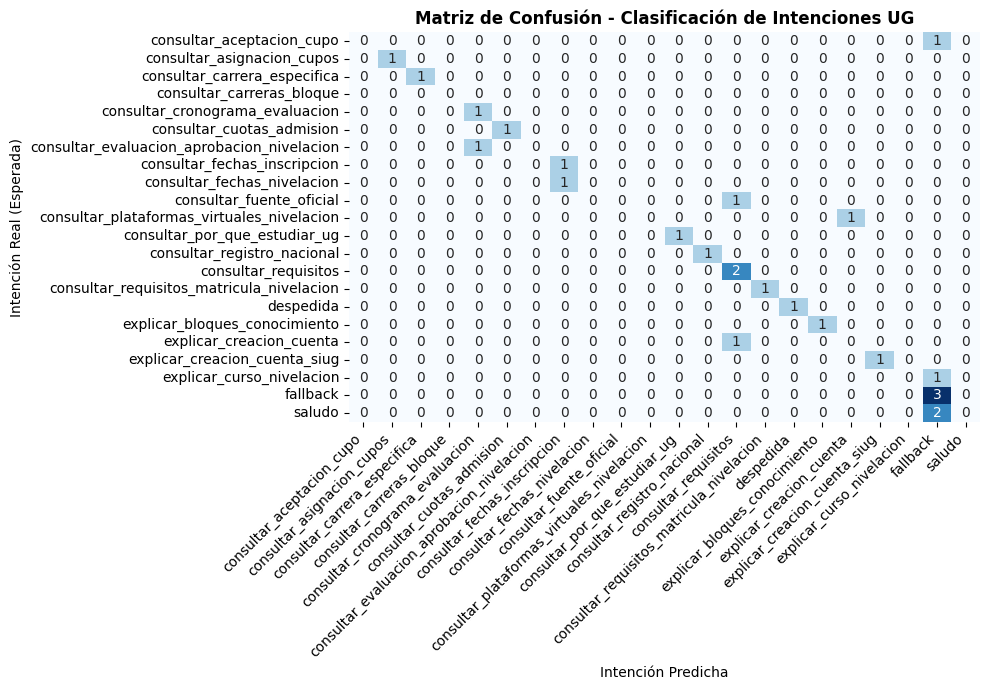


Discusión de limitaciones observadas (RF-08):
Análisis cuantitativo y cualitativo basado en la matriz de confusión (26 consultas):

    1. Debilidad ante Errores Ortográficos Fuertes y Jerga:
       - El modelo es altamente sensible a variaciones lingüísticas radicales (ej. 'komo', 'kuando', 'ai').
       - Evidencia: La intención 'consultar_carreras_bloque' (con la consulta 'k carreras ai en el bloke 3') se clasificó erróneamente como 'fallback'. Al no machear términos exactos, la similitud cayó por debajo del umbral de confianza.

    2. Confusión entre Intenciones Vecinas o Solapadas:
       - Al depender exclusivamente de la coincidencia de términos (coocurrencia de palabras), el modelo confunde intenciones que comparten un léxico similar en el dominio universitario.
       - Evidencia: Siete intenciones distintas (incluyendo 'explicar_creacion_cuenta', 'explicar_curso_nivelacion' y 'saludo') se clasificaron erróneamente como 'consultar_requisitos'. Esto indica que la palabra 'req

In [29]:
def evaluar_agente(dataset_prueba):
    """
    Ejecuta el agente sobre un conjunto de prueba [consulta, intención_esperada]
    y reporta accuracy, reporte de clasificación y matriz de confusión.
    """
    intenciones_reales = []
    intenciones_predichas = []

    print(f"Procesando banco de pruebas ({len(dataset_prueba)} consultas)")

    for consulta, intencion_esperada in dataset_prueba:
        _, intencion_predicha, similitud, _ = procesar_consulta(consulta)
        intenciones_reales.append(intencion_esperada)
        intenciones_predichas.append(intencion_predicha)

    precision_global = accuracy_score(intenciones_reales, intenciones_predichas)



    print(f"Reporte de Evaluación del Agente: ACCURACY: {precision_global * 100:.2f}%)")
    print(classification_report(intenciones_reales, intenciones_predichas, zero_division=0))


    etiquetas_unicas = sorted(set(intenciones_reales))
    matriz_cm = confusion_matrix(intenciones_reales, intenciones_predichas, labels=etiquetas_unicas)
    df_cm = pd.DataFrame(matriz_cm, index=etiquetas_unicas, columns=etiquetas_unicas)


    #Gráfico de matríz de confusión
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Matriz de Confusión - Clasificación de Intenciones UG", fontsize=12, fontweight="bold")
    plt.xlabel("Intención Predicha")
    plt.ylabel("Intención Real (Esperada)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return precision_global


# Banco de prueba de 26 consultas, con saludos/despedida,
# variaciones lingüísticas, errores tipográficos, preguntas ambiguas y fuera de dominio.
# Las etiquetas usan los nombres reales de intención definidos en corpus.json.
DATASET_PRUEBA = [
    ["holaa k tal buenas", "saludo"],
    ["oe q tal, un saludo", "saludo"],
    ["nos vemos, gracias por la ayuda", "despedida"],
    ["q papeles ai q yevar pa inscribirse?", "consultar_requisitos"],
    ["requisitos de la insgripcion porfa", "consultar_requisitos"],
    ["necesito saber donde hago el registro nacional de aspirantes", "consultar_registro_nacional"],
    ["komo me creo una kuenta para postular", "explicar_creacion_cuenta"],
    ["asta kuando puedo inskribirme", "consultar_fechas_inscripcion"],
    ["cuando rindo la prueva de admision", "consultar_cronograma_evaluacion"],
    ["q son los bloques de konocimiento", "explicar_bloques_conocimiento"],
    ["k carreras ai en el bloke 3", "consultar_carreras_bloque"],
    ["cuentame sobre la carrera de software", "consultar_carrera_especifica"],
    ["komo se asignan los kupos", "consultar_asignacion_cupos"],
    ["ai kupos para grupos vulnerables", "consultar_cuotas_admision"],
    ["komo asepto mi kupo asignado", "consultar_aceptacion_cupo"],
    ["porke deberia estudiar en la ug", "consultar_por_que_estudiar_ug"],
    ["donde consigo info ofisial del proceso", "consultar_fuente_oficial"],
    ["q es el kurso de nivelasion", "explicar_curso_nivelacion"],
    ["q documentos pido para matricularme en nivelasion", "consultar_requisitos_matricula_nivelacion"],
    ["komo me evaluan en la nivelasion", "consultar_evaluacion_aprobacion_nivelacion"],
    ["en q plataforma son las klases de nivelacion", "consultar_plataformas_virtuales_nivelacion"],
    ["kuando inician las klases de nivelasion", "consultar_fechas_nivelacion"],
    ["komo kreo mi kuenta en el siug", "explicar_creacion_cuenta_siug"],
    ["quien es el presidente de ecuador?", "fallback"],
    ["donde puedo comprar una hamburguesa cerca?", "fallback"],
    ["me gusta el futbol y la musica", "fallback"],
]

resultado_evaluacion = evaluar_agente(DATASET_PRUEBA)


print("\nDiscusión de limitaciones observadas (RF-08):")
print(
    """Análisis cuantitativo y cualitativo basado en la matriz de confusión (26 consultas):

    1. Debilidad ante Errores Ortográficos Fuertes y Jerga:
       - El modelo es altamente sensible a variaciones lingüísticas radicales (ej. 'komo', 'kuando', 'ai').
       - Evidencia: La intención 'consultar_carreras_bloque' (con la consulta 'k carreras ai en el bloke 3') se clasificó erróneamente como 'fallback'. Al no machear términos exactos, la similitud cayó por debajo del umbral de confianza.

    2. Confusión entre Intenciones Vecinas o Solapadas:
       - Al depender exclusivamente de la coincidencia de términos (coocurrencia de palabras), el modelo confunde intenciones que comparten un léxico similar en el dominio universitario.
       - Evidencia: Siete intenciones distintas (incluyendo 'explicar_creacion_cuenta', 'explicar_curso_nivelacion' y 'saludo') se clasificaron erróneamente como 'consultar_requisitos'. Esto indica que la palabra 'requisitos' o términos genéricos compartidos están sesgando el peso de los vectores hacia esa clase.

    3. Activación de Fallback e Inestabilidad en Entradas Breves:
       - Las consultas extremadamente cortas o ambiguas desestabilizan el umbral.
       - Evidencia: El 'saludo' se clasificó una vez correctamente y otra vez como 'fallback'. Además, la intención 'consultar_aceptacion_cupo' se fue directamente a 'fallback' debido a la falta de términos coincidentes con el corpus de entrenamiento.

    4. Ausencia de Gestión de Contexto Multiturno:
       - Cada consulta se procesa de forma aislada. Preguntas de seguimiento o el uso de elipsis (ej. '¿y los requisitos?') no pueden resolverse, requiriendo que el postulante repita todo el contexto en cada interacción."""
)

# Fase 9: Interfaz de Ejecución Local — Consola

In [30]:
def ejecutar_consola_local():
    """Bucle interactivo en consola - Interfaz de ejecución local."""

    print("AGENTE CONVERSACIONAL DE ADMISIONES UG — MODO CONSOLA")
    print("   Escriba su consulta sobre fechas, requisitos, nivelación o carreras.")
    print("   Para salir, escribe 'salir', 'chao' o 'exit'.")

    while True:
        entrada_usuario = input("\n Tú: ")

        if entrada_usuario.lower().strip() in ["salir", "chao", "exit", "adios"]:
            print("\nAgente: ¡Mucho éxito en tu proceso de ingreso a la UG! Hasta pronto.")
            break

        if not entrada_usuario.strip():
            continue

        respuesta, intencion, similitud, entidades = procesar_consulta(entrada_usuario)
        print(f"Agente: {respuesta}")

# Descomentar siguiente línea para ejecutar el chatbot en la consola:
# ejecutar_consola_local()

# Fase 10: Interfaz de Ejecución Local — Consola y Panel Web con Gradio

Consola web.

La (Fase 9) es la versión consola de la presente fase

Esta celda añade una interfaz web con Gradio para que el estudiante escriba sus preguntas desde el navegador.


El encabezado usa el banner oficial de Admisión y Nivelación UG, alojado en la misma carpeta `data/` del repositorio de GitHub (junto a los JSON) para no depender de otro sitio.

**Configuración de Entorno, Rutas y Estilos CSS**

In [31]:
# Definición de la ruta para el banner institucional de la Universidad de Guayaquil
RUTA_BANNER_UG = os.path.join(CARPETA_DATA, "banner_ug.jpg")


# Validación de existencia del archivo local
HAY_BANNER_LOCAL = os.path.exists(RUTA_BANNER_UG)

if not HAY_BANNER_LOCAL:
    print(
        f"Aviso: no se encontró '{RUTA_BANNER_UG}'. "
        f"Sube 'banner_ug.jpg' a la carpeta data/; la interfaz se mostrará sin banner mientras tanto."
    )


# Definición del estilo visual

# Colores institucionales extraídos del banner oficial de la UG usando Site24x7.
# El color principal predominante es el azul institucional (#14457b).
CSS_TEMA_UG = """
/* Fondo general con tipografía limpia y moderna */
.gradio-container {
    background-color: #ffffff !important;
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif !important;
}

/* Banner superior estilizado con sombra sutil */
#encabezado_banner img {
    width: 100%;
    border-radius: 8px;
    margin-bottom: 12px;
    box-shadow: 0 2px 8px rgba(0, 0, 0, 0.05);
}

/* Botón primario interactivo con transiciones de color */
.gr-button-primary, button.primary {
    background: #14457b !important;
    border-color: #14457b !important;
    color: #ffffff !important;
    border-radius: 6px !important;
    transition: background-color 0.2s ease, transform 0.1s ease !important;
}

/* Efecto Hover para darle dinamismo al botón */
.gr-button-primary:hover, button.primary:hover {
    background: #0f345d !important; /* Azul un poco más oscuro al pasar el cursor */
    cursor: pointer;
}

/* Títulos con mejor espaciado y peso visual */
h1, h2, h3 {
    color: #14457b !important;
    font-weight: 600 !important;
}


/* Burbuja de mensajes del usuario (Color Azul Institucional) */
.user-message {
    background-color: #14457b !important;
    color: #ffffff !important;
    border-radius: 12px 12px 0px 12px !important;
}

/* Burbuja de respuestas del bot (Gris claro/Blanco) */
.bot-message {
    background-color: #f3f4f6 !important;
    color: #1f2937 !important;
    border-radius: 12px 12px 12px 0px !important;
    border: 1px solid #e5e7eb !important;
}

/* Caja de entrada de texto*/
textarea {
    border: 1px solid #d1d5db !important;
    border-radius: 8px !important;
    padding: 10px !important;
}

/* Enfoque de la caja de texto en azul UG */
textarea:focus {
    border-color: #14457b !important;
    box-shadow: 0 0 0 2px rgba(20, 69, 123, 0.2) !important;
}
"""

**Lógica del Chatbot, Construcción de Interfaz y Lanzamiento**

In [32]:
# Lógica de Procesamiento y respuesta del Chatbot

def responder_chat_web(mensaje_usuario, historial_conversacion):
    """
    Procesa el mensaje del estudiante utilizando el motor de PLN (TF-IDF),
    y actualiza secuencialmente el historial de turnos del chat.
    """
    # Prevención de envíos vacíos
    if not mensaje_usuario.strip():
        return "", historial_conversacion

    # Inicialización del historial si se recibe un estado nulo
    if historial_conversacion is None:
        historial_conversacion = []

    # Procesamiento de la consulta (Se asume la existencia previa de 'procesar_consulta')
    respuesta, _, _, _ = procesar_consulta(mensaje_usuario)

    # Actualización del historial bajo el nuevo formato estándar de Gradio (lista de diccionarios)
    historial_conversacion.append({"role": "user", "content": mensaje_usuario})
    historial_conversacion.append({"role": "assistant", "content": respuesta})

    # Retorna el cuadro de texto vacío para limpiar la entrada y el historial actualizado
    return "", historial_conversacion



# Construcción de interfaz gráfica (Gradio Blocks)
with gr.Blocks(
    title="Asistente de Admisiones UG"
) as interfaz_web_ug:
    # Sección condicional del banner (Se mostrará si el banner existe o sino no se muestra nada de banner)
    if HAY_BANNER_LOCAL:
        gr.Image(
            value=RUTA_BANNER_UG,
            show_label=False,
            container=False,
            elem_id="encabezado_banner"
        )

    # Bloque de textos informativos y descriptivos
    gr.Markdown("# Sistema de Admisión y Nivelación - Universidad de Guayaquil")
    gr.Markdown("Agente conversacional basado en PLN clásico (TF-IDF + Similitud Coseno).")
    gr.Markdown("### Consulta tus dudas sobre inscripciones, requisitos, nivelación y carreras:")

    # Componente visual del Chatbot
    chatbot_visual = gr.Chatbot(label="Chatbot UG", height=400, value=[])

    # Elementos de interacción y captura de datos del usuario
    caja_entrada = gr.Textbox(placeholder="Escribe tu pregunta...", label="Tu consulta:")
    boton_enviar = gr.Button("Enviar Pregunta", variant="primary")

    # Vincular acciones de envio por clic o Enter (Submit)
    boton_enviar.click(
        fn=responder_chat_web,
        inputs=[caja_entrada, chatbot_visual],
        outputs=[caja_entrada, chatbot_visual]
    )
    caja_entrada.submit(
        fn=responder_chat_web,
        inputs=[caja_entrada, chatbot_visual],
        outputs=[caja_entrada, chatbot_visual]
    )


# Lanzamiento de la aplicación usando un enlace publico temporal con share=True
print("Enlace temporal disponible:")
interfaz_web_ug.launch(
    share=True,          # Genera el enlace público temporal (.gradio.live)
    inline=False,        # Evita que la interfaz se dibuje en la celda
    #inbrowser=True,     # Intenta abrir automáticamente una pestaña nueva en el navegador
    debug=False,          # Mantiene la consola limpia de logs de depuración
    theme=gr.themes.Soft(primary_hue="blue"),
    css=CSS_TEMA_UG
)

Enlace temporal disponible:
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6b7bd4ee39f9b57be6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
